<a href="https://colab.research.google.com/github/javisagredo-dev/Evaluacion2_Prog_DS/blob/main/03_aprendizaje_supervisado(optimizado).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aprendizaje supervisado: optimización de hiperparámetros

## Importaciones necesarias

In [ ]:
import pickle
from sklearn.model_selection import GridSearchCV
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import time
import warnings
warnings.filterwarnings('ignore')

## Carga y lectura de datos

In [ ]:
drive.mount('/content/drive')
df = pd.read_excel('/content/drive/MyDrive/Ciencia de Datos Collab/Programación para la ciencia de datos/Evaluacion_2/Raw/Dry_Bean_Dataset.xlsx')

Mounted at /content/drive


## Preparación de datos para optimización de hiperparámetros

In [ ]:
df_model = df.copy()

X = df_model.drop('Class', axis=1)
le = LabelEncoder()
y = le.fit_transform(df_model['Class'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Carga de las variables guardadas

In [ ]:
ruta_pkl = "/content/drive/MyDrive/Ciencia de Datos Collab/Programación para la ciencia de datos/Evaluacion_2/Processed/resultados_modelos.pkl"

with open(ruta_pkl, 'rb') as f:
    datos = pickle.load(f)

accuracy_dt = datos['accuracy_dt']
accuracy_lr = datos['accuracy_lr']
accuracy_svm = datos['accuracy_svm']
f1_dt = datos['f1_dt']
f1_lr = datos['f1_lr']
f1_svm = datos['f1_svm']
y_pred_dt = datos['y_pred_dt']
y_pred_lr = datos['y_pred_lr']
y_pred_svm = datos['y_pred_svm']
y_test = datos['y_test']
le = datos['le']

print("Variables importadas correctamente")

Variables importadas correctamente


## GridSearchCV - Optimización de Árbol de Decisión

In [ ]:
param_grid_dt = {
    'max_depth': [8, 9, 10, 11],
    'criterion': ['entropy'],
    'min_samples_split': [10, 15, 20, 30],
    'min_samples_leaf': [2, 4, 6, 8],
    'max_features': [None, 'sqrt', 'log2']
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

start_time = time.time()
grid_dt.fit(X_train, y_train)
time_grid_dt = time.time() - start_time

print(f" Tiempo: {time_grid_dt:.2f} segundos")
print(f" Mejores hiperparámetros: {grid_dt.best_params_}")
print(f" Mejor accuracy (cv): {grid_dt.best_score_:.4f}")

y_pred_grid_dt = grid_dt.predict(X_test)
print(f" Accuracy en test: {accuracy_score(y_test, y_pred_grid_dt):.4f}")

 Tiempo: 143.11 segundos
 Mejores hiperparámetros: {'criterion': 'entropy', 'max_depth': 9, 'max_features': None, 'min_samples_leaf': 6, 'min_samples_split': 20}
 Mejor accuracy (cv): 0.9119
 Accuracy en test: 0.9049


## GridSearchCV - Optimización de Regresión Logística

In [ ]:
param_grid_lr = {
    'C': [50, 100, 200, 500, 1000],
    'solver': ['lbfgs', 'newton-cg'],
    'max_iter': [2000],
    'penalty': ['l2']
}

grid_lr = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid_lr,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

start_time = time.time()
grid_lr.fit(X_train_scaled, y_train)
time_grid_lr = time.time() - start_time

print(f" Tiempo: {time_grid_lr:.2f} segundos")
print(f" Mejores hiperparámetros: {grid_lr.best_params_}")
print(f" Mejor accuracy (cv): {grid_lr.best_score_:.4f}")

y_pred_grid_lr = grid_lr.predict(X_test_scaled)
print(f" Accuracy en test: {accuracy_score(y_test, y_pred_grid_lr):.4f}")

 Tiempo: 41.96 segundos
 Mejores hiperparámetros: {'C': 1000, 'max_iter': 2000, 'penalty': 'l2', 'solver': 'newton-cg'}
 Mejor accuracy (cv): 0.9275
 Accuracy en test: 0.9214


## GridSearchCV - Optimización de SVM

In [ ]:
param_grid_svm = {
    'C': [30, 40, 50, 60, 80, 100],
    'kernel': ['rbf'],
    'gamma': ['scale', 0.01, 0.05, 0.1, 0.2]
}

grid_svm = GridSearchCV(
    SVC(random_state=42),
    param_grid_svm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

start_time = time.time()
grid_svm.fit(X_train_scaled, y_train)
time_grid_svm = time.time() - start_time

print(f" Tiempo: {time_grid_svm:.2f} segundos")
print(f" Mejores hiperparámetros: {grid_svm.best_params_}")
print(f" Mejor accuracy (cv): {grid_svm.best_score_:.4f}")

y_pred_grid_svm = grid_svm.predict(X_test_scaled)
print(f" Accuracy en test: {accuracy_score(y_test, y_pred_grid_svm):.4f}")

 Tiempo: 148.18 segundos
 Mejores hiperparámetros: {'C': 30, 'gamma': 'scale', 'kernel': 'rbf'}
 Mejor accuracy (cv): 0.9347
 Accuracy en test: 0.9269


## Comparación final: modelos base vs optimizados

In [ ]:
comparison_final = pd.DataFrame({
    'Modelo': ['Árbol de Decisión', 'Regresión Logística', 'SVM'],
    'Accuracy antes': [accuracy_dt, accuracy_lr, accuracy_svm],
    'Accuracy después': [
        accuracy_score(y_test, y_pred_grid_dt),
        accuracy_score(y_test, y_pred_grid_lr),
        accuracy_score(y_test, y_pred_grid_svm)
    ],
    'Mejora': [
        accuracy_score(y_test, y_pred_grid_dt) - accuracy_dt,
        accuracy_score(y_test, y_pred_grid_lr) - accuracy_lr,
        accuracy_score(y_test, y_pred_grid_svm) - accuracy_svm
    ]
})

print(comparison_final.to_string(index=False))

best = comparison_final.loc[comparison_final['Accuracy después'].idxmax()]
print(f"\n{'='*60}")
print(f"MEJOR MODELO FINAL: {best['Modelo']}")
print(f"Accuracy: {best['Accuracy después']:.4f}")
print(f"{'='*60}")

             Modelo  Accuracy antes  Accuracy después    Mejora
  Árbol de Decisión        0.907088          0.904884 -0.002203
Regresión Logística        0.921410          0.921410  0.000000
                SVM        0.922145          0.926919  0.004774

MEJOR MODELO FINAL: SVM
Accuracy: 0.9269


## Gráfico comparativo: Antes vs Después de optimización (Accuracy)

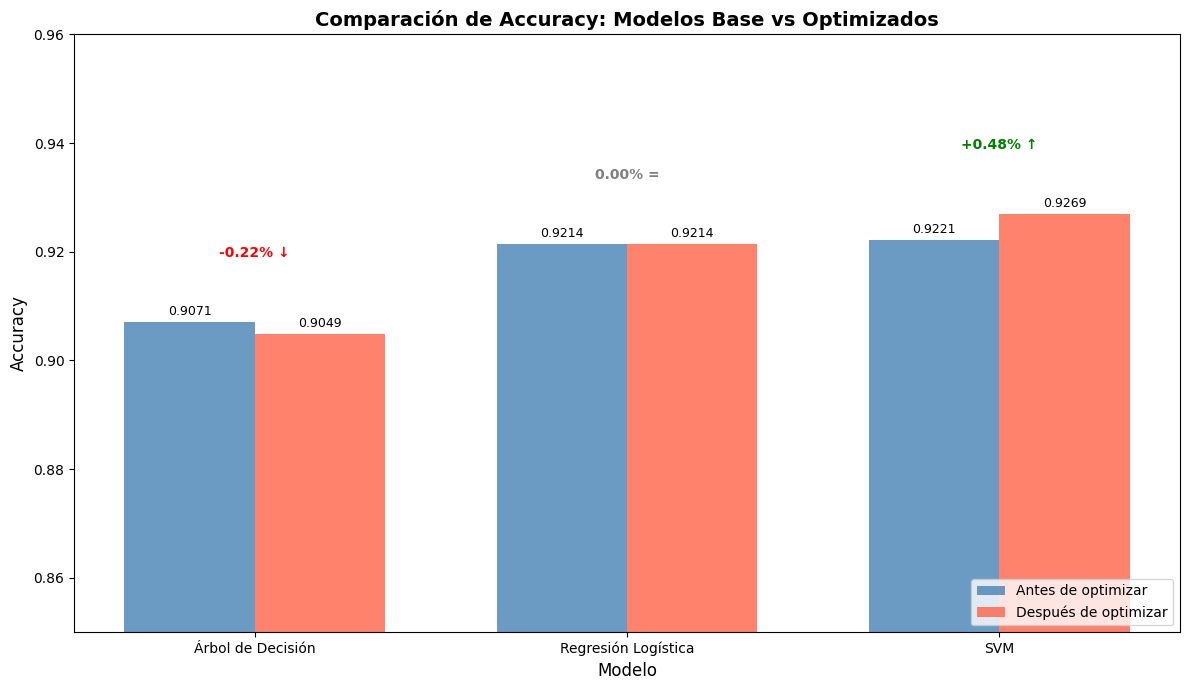

In [ ]:

modelos = ['Árbol de Decisión', 'Regresión Logística', 'SVM']
accuracy_antes = [accuracy_dt, accuracy_lr, accuracy_svm]
accuracy_despues = [
    accuracy_score(y_test, y_pred_grid_dt),
    accuracy_score(y_test, y_pred_grid_lr),
    accuracy_score(y_test, y_pred_grid_svm)
]

x = np.arange(len(modelos))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))

bars1 = ax.bar(x - width/2, accuracy_antes, width, label='Antes de optimizar', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, accuracy_despues, width, label='Después de optimizar', color='tomato', alpha=0.8)


ax.set_xlabel('Modelo', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Comparación de Accuracy: Modelos Base vs Optimizados', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(modelos)
ax.legend(loc='lower right')
ax.set_ylim([0.85, 0.96])


for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)


for i, (antes, despues) in enumerate(zip(accuracy_antes, accuracy_despues)):
    mejora = (despues - antes) * 100
    if mejora > 0:
        color = 'green'
        signo = '+'
        texto = f'{signo}{mejora:.2f}% ↑'
    elif mejora < 0:
        color = 'red'
        signo = ''
        texto = f'{signo}{mejora:.2f}% ↓'
    else:
        color = 'gray'
        texto = '0.00% ='


    ax.annotate(texto,
                xy=(i, max(antes, despues) + 0.012),
                ha='center', fontsize=10, fontweight='bold', color=color)

plt.tight_layout()
plt.show()

## Gráfico comparativo: Antes vs Después de optimización (F1-Score)

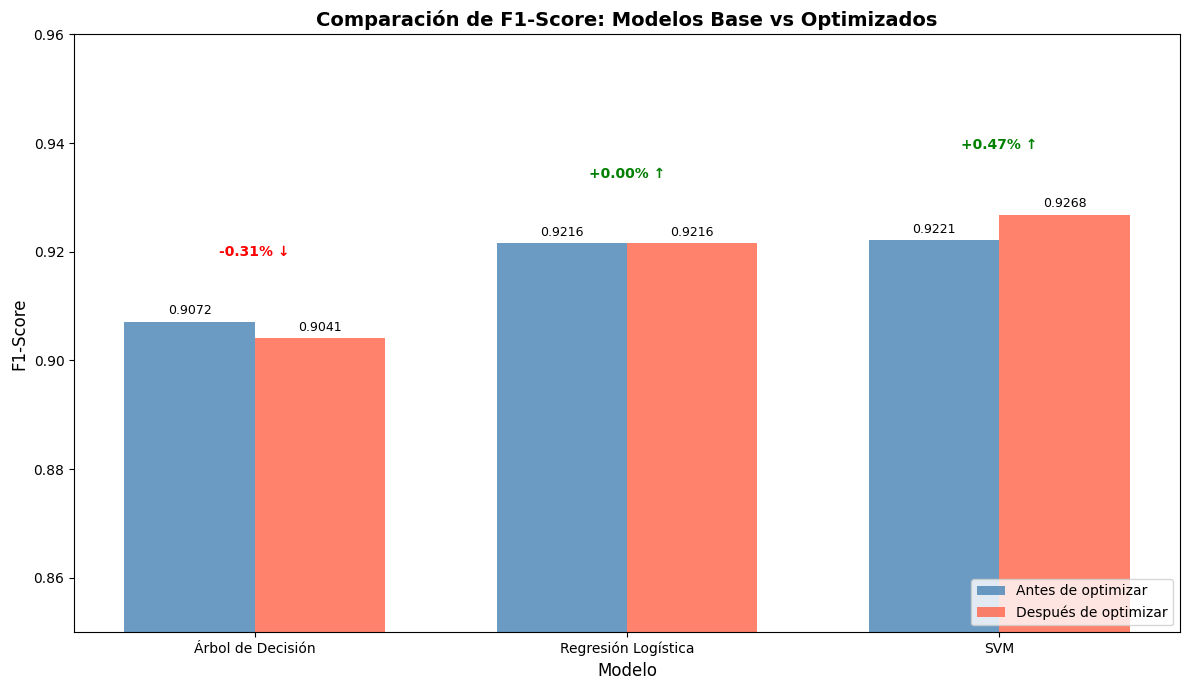

In [ ]:
modelos = ['Árbol de Decisión', 'Regresión Logística', 'SVM']
f1_antes = [f1_dt, f1_lr, f1_svm]
f1_despues = [
    f1_score(y_test, y_pred_grid_dt, average='weighted'),
    f1_score(y_test, y_pred_grid_lr, average='weighted'),
    f1_score(y_test, y_pred_grid_svm, average='weighted')
]

x = np.arange(len(modelos))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))

bars1 = ax.bar(x - width/2, f1_antes, width, label='Antes de optimizar', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, f1_despues, width, label='Después de optimizar', color='tomato', alpha=0.8)


ax.set_xlabel('Modelo', fontsize=12)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title('Comparación de F1-Score: Modelos Base vs Optimizados', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(modelos)
ax.legend(loc='lower right')
ax.set_ylim([0.85, 0.96])


for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)


for i, (antes, despues) in enumerate(zip(f1_antes, f1_despues)):
    mejora = (despues - antes) * 100
    if mejora > 0:
        color = 'green'
        signo = '+'
        texto = f'{signo}{mejora:.2f}% ↑'
    elif mejora < 0:
        color = 'red'
        signo = ''
        texto = f'{signo}{mejora:.2f}% ↓'
    else:
        color = 'gray'
        texto = '0.00% ='


    ax.annotate(texto,
                xy=(i, max(antes, despues) + 0.012),
                ha='center', fontsize=10, fontweight='bold', color=color)

plt.tight_layout()
plt.show()

## Optimización avanzada de SVM

### Eliminacion de variables mas redundantes

In [ ]:
df_svm = df_model.copy()


variables_reducidas = [
    'Area', 'MajorAxisLength', 'Eccentricity', 'Extent', 'Solidity',
    'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor4'
]

X_svm = df_svm[variables_reducidas]
y_svm = le.fit_transform(df_svm['Class'])

print(f"Variables originales: 16")
print(f"Variables reducidas: {len(variables_reducidas)}")
print(f"Eliminadas: {16 - len(variables_reducidas)}")


X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X_svm, y_svm, test_size=0.2, random_state=42, stratify=y_svm
)

scaler_svm = StandardScaler()
X_train_svm_scaled = scaler_svm.fit_transform(X_train_svm)
X_test_svm_scaled = scaler_svm.transform(X_test_svm)

print(f"\nShape train: {X_train_svm.shape}")
print(f"Shape test: {X_test_svm.shape}")

Variables originales: 16
Variables reducidas: 10
Eliminadas: 6

Shape train: (10888, 10)
Shape test: (2723, 10)


### SVM con variables reducidas

In [ ]:
svm_reduced = SVC(C=30, gamma='scale', kernel='rbf', random_state=42)

start_time = time.time()
svm_reduced.fit(X_train_svm_scaled, y_train_svm)
time_svm_r = time.time() - start_time

y_pred_svm_r = svm_reduced.predict(X_test_svm_scaled)

acc_svm_r = accuracy_score(y_test_svm, y_pred_svm_r)
f1_svm_r = f1_score(y_test_svm, y_pred_svm_r, average='weighted')

print(f"Tiempo: {time_svm_r:.2f} segundos")
print(f"Accuracy: {acc_svm_r:.4f}")
print(f"F1-Score: {f1_svm_r:.4f}")

Tiempo: 2.94 segundos
Accuracy: 0.9269
F1-Score: 0.9268


### RANDOM FOREST con variables reducidas

In [ ]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

start_time = time.time()
rf.fit(X_train_svm, y_train_svm)
time_rf = time.time() - start_time

y_pred_rf = rf.predict(X_test_svm)

acc_rf = accuracy_score(y_test_svm, y_pred_rf)
f1_rf = f1_score(y_test_svm, y_pred_rf, average='weighted')

print(f"Tiempo: {time_rf:.2f} segundos")
print(f"Accuracy: {acc_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")

Tiempo: 12.56 segundos
Accuracy: 0.9229
F1-Score: 0.9228


### XGBOOST con variables reducidas

In [ ]:
xgb = XGBClassifier(n_estimators=200, random_state=42, n_jobs=-1, eval_metric='mlogloss')

start_time = time.time()
xgb.fit(X_train_svm, y_train_svm)
time_xgb = time.time() - start_time

y_pred_xgb = xgb.predict(X_test_svm)

acc_xgb = accuracy_score(y_test_svm, y_pred_xgb)
f1_xgb = f1_score(y_test_svm, y_pred_xgb, average='weighted')

print(f"Tiempo: {time_xgb:.2f} segundos")
print(f"Accuracy: {acc_xgb:.4f}")
print(f"F1-Score: {f1_xgb:.4f}")

Tiempo: 8.96 segundos
Accuracy: 0.9240
F1-Score: 0.9240


## Conclusiones

Árbol de Decisión

La optimización corrigió el overfitting que tenía con la configuración inicial (max_depth=10), donde el modelo memorizaba el conjunto de entrenamiento. Aunque el accuracy bajó levemente (-0.07%), el modelo optimizado generaliza mejor con max_depth=9, criterion='entropy', min_samples_leaf=6 y min_samples_split=20. La configuración original parecía mejor solo porque inflaba el rendimiento aprendiendo de memoria los datos.

Regresión Logística

La optimización confirmó que el modelo ya estaba en su óptimo desde la configuración inicial. Ni ampliando el rango de C hasta 1000 ni probando distintos solvers se logró una mejora real (0.00% de cambio). Esto es esperable porque la Regresión Logística es un modelo lineal, y su capacidad de mejora está limitada por la naturaleza misma del algoritmo, no por sus hiperparámetros.

Variables redundantes

El análisis de correlación reveló que varias variables miden esencialmente la misma información: Area, ConvexArea, EquivDiameter y Perimeter están casi perfectamente correlacionadas (0.97-1.00) porque todas miden tamaño; AspectRation y Eccentricity (0.92) miden elongación; y Compactness y ShapeFactor3 (1.00) miden redondez con fórmulas distintas pero matemáticamente equivalentes. Se realizó un experimento eliminando estas redundancias, reduciendo de 16 a 10 variables. El resultado fue revelador: el SVM mantuvo exactamente el mismo accuracy (0.9269), lo que confirma que las variables eliminadas no aportaban información nueva al modelo, solo ruido computacional. Esto demuestra que en datasets con alta colinealidad, menos features pueden ser tan efectivas como muchas, y con un costo computacional menor.

SVM

El SVM fue el único modelo que ganó accuracy real con la optimización (+0.48%), pasando de 0.9221 a 0.9269. La mejora vino principalmente de cambiar el kernel de linear a rbf, lo que le permitió capturar relaciones no lineales entre las features del grano. Los hiperparámetros finales C=30, gamma='scale', kernel='rbf' lograron el mejor balance entre flexibilidad y generalización.
Para verificar si era posible superar este rendimiento, se compararon modelos más complejos sobre el mismo dataset reducido: Random Forest alcanzó 92.32% y XGBoost 92.40%, ambos por debajo del SVM optimizado (92.69%). Esto es poco común en datos tabulares, donde los métodos basados en árboles suelen dominar, pero ocurre cuando las clases tienen relaciones suaves y bastante separables, escenario donde el kernel rbf del SVM brilla. La conclusión técnica es clara: el límite práctico de este dataset con algoritmos clásicos está en aproximadamente 92.7%, y el SVM con kernel rbf es el modelo óptimo para este problema. Superar este techo requeriría técnicas más exóticas (ensemble stacking, redes neuronales profundas o feature engineering manual), cuyo costo de implementación no se justifica para una mejora marginal.


## Exportación de variables para análisis final

In [24]:
variables_svm = {

    'X_train_svm': X_train_svm,
    'X_test_svm': X_test_svm,
    'y_train_svm': y_train_svm,
    'y_test_svm': y_test_svm,
    'X_train_svm_scaled': X_train_svm_scaled,
    'X_test_svm_scaled': X_test_svm_scaled,

    'svm_reduced': svm_reduced,
    'scaler_svm': scaler_svm,


    'acc_svm_r': acc_svm_r,
    'f1_svm_r': f1_svm_r,


    'y_pred_svm_r': y_pred_svm_r,


    'variables_reducidas': variables_reducidas,


    'le': le
}

ruta_svm = '/content/drive/MyDrive/Ciencia de Datos Collab/Programación para la ciencia de datos/Evaluacion_2/Processed/resultados_svm_optimizado.pkl'

with open(ruta_svm, 'wb') as f:
    pickle.dump(variables_svm, f)

print("Variables del SVM optimizado guardadas en Drive")

Variables del SVM optimizado guardadas en Drive
